<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 15: ANOVA Assumptions and Complex Designs
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 13-14

## 1. Introduction to ANOVA Assumptions
Parametric ANOVA relies on several key assumptions to ensure that the F-statistic and resulting probability values are accurate.

### Key Assumptions:
* **Homogeneity of Variances (Homoscedasticity):** Parametric ANOVA assumes data for each treatment come from populations that share the same variance. Unequal variances are referred to as heteroscedasticity.
* **Normality:** Parametric tests assume that the residuals (the differences between individual observations and the group mean) are normally distributed.
* **Independence:** Every sampling or experimental unit within a treatment must be chosen independently of the others. This is primarily a consequence of good experimental design, where all possible units have an equal likelihood of being selected.

## 2. Testing and Addressing Homogeneity
If variances are unequal, the ANOVA may produce an unrealistic F statistic. However, ANOVA is relatively "robust" to departures from homoscedasticity. In geological data, it is common to see the variance increase as the mean increases.

### The "4:1 Rule"
A formal test may not be required if the ratio of the largest variance to the smallest variance in the study does not exceed 4:1. If it is greater, you should examine the data to see where differences occur.

### The Levene Test
When you want to formally test a specific hypothesis about variance, the Levene test is recommended.
* It calculates the absolute difference between each individual replicate and its respective treatment mean.
* It then performs a standard single-factor ANOVA on these absolute differences.
* A significant F ratio indicates that sample variances differ.

In [5]:
import scipy.stats as stats
import numpy as np

# Example data for three treatments representing the Levene test logic
# Treatment 1 has a noticeably larger variance
treatment_1 = [1, 3, 4, 6, 7, 9, 10, 12, 25]
treatment_2 = [5, 6, 5, 7, 6, 5, 8, 6, 7]
treatment_3 = [10, 11, 12, 10, 11, 10, 13, 11, 12]

# Perform Levene's Test
stat, p = stats.levene(treatment_1, treatment_2, treatment_3)
print(f'Levene Statistic: {stat:.4f}, p-value: {p:.4f}')

if p < 0.05:
    print("Variances are significantly different (Heteroscedasticity).")
else:
    print("Variances are homogeneous (Homoscedasticity).")

Levene Statistic: 4.6314, p-value: 0.0199
Variances are significantly different (Heteroscedasticity).


## 3. Normality and Visualizing Data
It is highly important to inspect the distribution of data before performing a test. One of the most effective ways to check for normality and identify outliers is through box-and-whiskers plots or violin plots.

### Box-and-Whiskers Plot Components:
* **Hinges:** The data is split into halves to find the lower and upper quartiles, which define the limits of the box (the hinges).
* **Interquartile Range (IQR):** Calculated as the difference between the quartiles.
* **Whiskers:** The maximum potential length of each whisker is defined as 1.5 times the IQR. Any data point beyond this range is typically treated as an outlier.

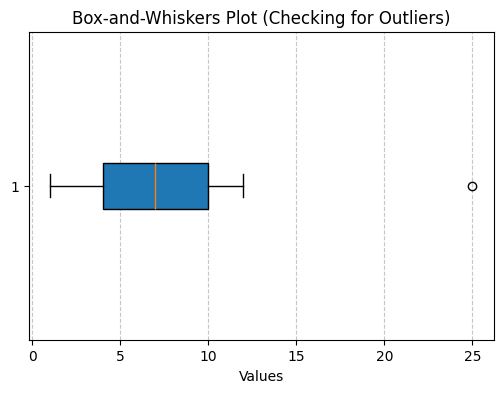

In [6]:
import matplotlib.pyplot as plt

# Example dataset to visualize outliers
data = [1, 3, 4, 6, 7, 9, 10, 12, 25]

plt.figure(figsize=(6, 4))
plt.boxplot(data, vert=False, patch_artist=True)
plt.title("Box-and-Whiskers Plot (Checking for Outliers)")
plt.xlabel("Values")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 4. Data Transformations
Transformations are used to change the distribution of a dataset so it more closely resembles a normal distribution and stabilizes variances (achieving homogeneity). Transforming data is a mathematically sound practice; many geological phenomena naturally follow nonlinear relationships, like the Richter Scale or pH Scale. If you transform your data, you must also transform your null and alternate hypotheses to match.

### Common Transformation Types in Geostatistics:
* **Logarithmic (Log):** Used for data that is positively skewed, which is common in geological samples like mineral concentrations.
* **Square Root:** Frequently applied to count data (e.g., number of crystals in a thin section) where the variance tends to be proportional to the mean.
* **Arcsine:** Used for data expressed as proportions or percentages, stretching data near 0 and 1 into a normal, continuous range.

In [7]:
# Example of applying a mathematical transformation uniformly to a dataset
data_raw = np.array([1, 4, 9, 16, 25, 36, 49, 64, 81, 100])

# Applying Square Root Transformation
data_transformed = np.sqrt(data_raw)

print(f"Original Data Variance: {np.var(data_raw):.2f}")
print(f"Transformed Data Variance: {np.var(data_transformed):.2f}")

Original Data Variance: 1051.05
Transformed Data Variance: 8.25


## 5. Two-Factor ANOVA Without Replication
This experimental design is typically used when researchers face a shortage of sampling units or when treatments are highly expensive, making multiple replicates impossible.

### Key Characteristics:
* **No Separate Error Estimate:** Because there is only one replicate per cell, the single data point is identical to the cell mean.
* **Assuming No Interaction:** To estimate the error and perform the analysis, the statistical model must assume that there is no interaction between the two factors. The denominator for the mean squares combines interaction and error terms by subtracting Factor A and B from the total variation.
* **Example Application:** Oil geologists drilling single core samples at specific locations and logging them at specific depths.

## 6. Randomized Blocks
The randomized block design is used when experiments are conducted in environments with significant spatial variation. Researchers distribute replicates of each treatment evenly across the landscape by subdividing the area into blocks.

**Practical Example:** A scientist testing anti-parasite treatments on pearl oysters. Because factors like water depth, temperature, and currents vary drastically, the scientist used five parallel longlines as separate "blocks". One replicate of each treatment was randomly assigned within each longline, allowing the experiment to be analyzed using a two-factor ANOVA without replication.

## 7. Nested (Hierarchical) ANOVA
A nested ANOVA is necessary when an experimental design includes subgroups that are "nested" within main factor levels. Because the design is non-orthogonal (every level of one factor does not occur with every level of the other), a standard two-factor ANOVA cannot be used.

**Example:** Testing methods for preventing heavy metals from leaching into groundwater.
* **Main Treatments:** Control, Chlorapatite, and Fluorapatite.
* **Nested Subgroups:** Three distinct test plots are nested within each treatment group.
* **Replication:** Multiple replicates of groundwater run-off were analyzed from each individual plot.

### Statistical Logic:
* **Factor A (Main Treatment) F-Ratio:** The Mean Square (MS) for Factor A is divided by the MS for the nested subgroups, denoted as B(A). This isolates Factor A by comparing it against variation that contains everything except Factor A (subgroup variation plus error).
* **Factor B(A) (Nested Subgroups) F-Ratio:** The MS for Factor B(A) is divided by the Mean Square error (residual error), isolating specific variation contributed by natural differences between the subgroups.

In [8]:
import pandas as pd

# Creating a summary dataframe to map out the Nested ANOVA structure
nested_data_structure = {
    'Treatment (Factor A)': ['Control', 'Control', 'Control', 'Chlorapatite', 'Chlorapatite', 'Chlorapatite', 'Fluorapatite', 'Fluorapatite', 'Fluorapatite'],
    'Nested Plot (Factor B(A))': ['Plot A', 'Plot B', 'Plot C', 'Plot D', 'Plot E', 'Plot F', 'Plot G', 'Plot H', 'Plot I'],
    'Replicates (Water Samples)': ['n=12', 'n=12', 'n=12', 'n=12', 'n=12', 'n=12', 'n=12', 'n=12', 'n=12']
}

df_nested = pd.DataFrame(nested_data_structure)
print("Nested Experimental Design Structure:")
display(df_nested)

Nested Experimental Design Structure:


,Treatment (Factor A),Nested Plot (Factor B(A)),Replicates (Water Samples)
0,Control,Plot A,n=12
1,Control,Plot B,n=12
2,Control,Plot C,n=12
3,Chlorapatite,Plot D,n=12
4,Chlorapatite,Plot E,n=12
5,Chlorapatite,Plot F,n=12
6,Fluorapatite,Plot G,n=12
7,Fluorapatite,Plot H,n=12
8,Fluorapatite,Plot I,n=12


## 8. Simulating Data for Nested ANOVA
To demonstrate how a Nested ANOVA is calculated in practice, we will simulate a dataset based on the example of preventing heavy metals (like lead) from leaching into groundwater.

We will simulate:
* **3 Treatments:** Control, Chlorapatite, and Fluorapatite.
* **3 Plots per Treatment:** 9 plots total.
* **12 Replicates per Plot:** 108 total water samples.

The code below generates this data, intentionally creating a large difference between the Control group and the Apatite treatments, as well as slight natural variations between individual plots.

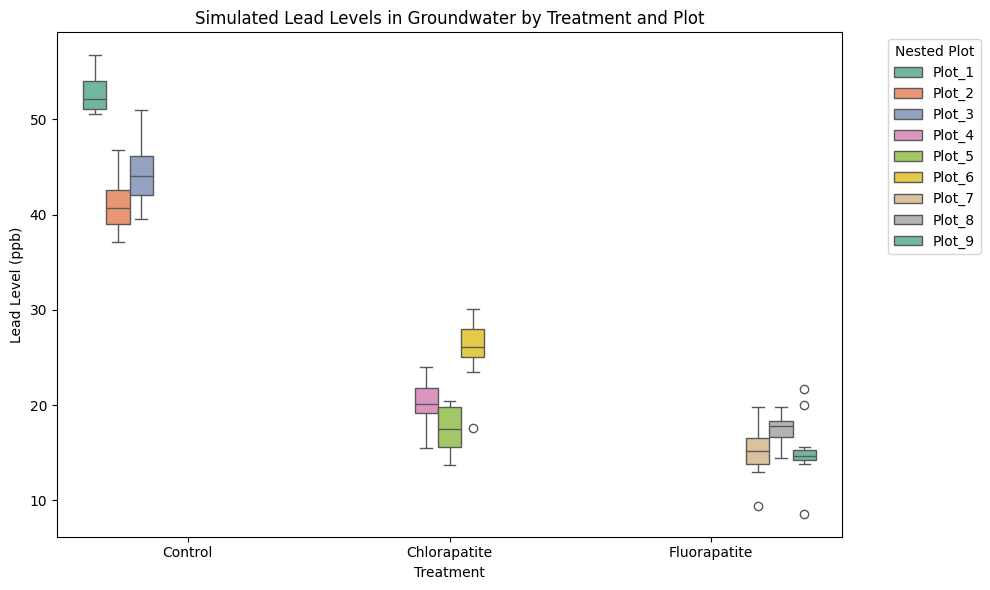

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Define experimental structure
treatments = ['Control', 'Chlorapatite', 'Fluorapatite']
plots_per_treatment = 3
replicates_per_plot = 12

data = []
plot_id = 1

# Generate simulated data
for treatment in treatments:
    # Baseline lead levels (ppb) based on treatment efficacy
    if treatment == 'Control':
        base_lead = 50.0
    elif treatment == 'Chlorapatite':
        base_lead = 20.0
    else:
        base_lead = 15.0

    for _ in range(plots_per_treatment):
        # Add random variation for each specific plot (the nested effect)
        plot_effect = np.random.normal(0, 4)

        for _ in range(replicates_per_plot):
            # Add random variation for each water sample (the residual error)
            lead_level = base_lead + plot_effect + np.random.normal(0, 3)
            data.append({
                'Treatment': treatment,
                'Plot': f'Plot_{plot_id}',
                'Lead_Level': lead_level
            })

        plot_id += 1

# Convert to DataFrame
df_nested_data = pd.DataFrame(data)

# Visualize the nested data
plt.figure(figsize=(10, 6))
sns.boxplot(x='Treatment', y='Lead_Level', hue='Plot', data=df_nested_data, palette='Set2')
plt.title('Simulated Lead Levels in Groundwater by Treatment and Plot')
plt.ylabel('Lead Level (ppb)')
plt.legend(title='Nested Plot', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Calculating Nested ANOVA F-Ratios
Standard ANOVA functions in Python (like `statsmodels` or `scipy.stats`) default to dividing all Mean Squares by the Residual Mean Square error. However, as established in our statistical logic:

1. **Factor A F-ratio:** The variation in Factor A includes the effect of Factor A + Factor B(A) + error. To isolate Factor A, we must compare it against the subgroup variation plus error. Therefore, we **divide the MS for Factor A by the MS for Factor B(A)**.
2. **Factor B(A) F-ratio:** We divide the MS for Factor B(A) by the Mean Square error to isolate the specific variation contributed by the subgroups.

We will use `statsmodels` to extract the Sum of Squares and Degrees of Freedom, and then manually calculate the correct F-ratios and P-values.

In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# Fit the OLS model
# We use + C(Plot) instead of an interaction term because Plot_1 through Plot_9 are unique.
model = ols('Lead_Level ~ C(Treatment) + C(Plot)', data=df_nested_data).fit()

# Generate the standard ANOVA table using Type 1 Sum of Squares (sequential)
# This perfectly partitions Treatment first, then Plot(Treatment)
anova_raw = sm.stats.anova_lm(model, typ=1)

# Extract Degrees of Freedom and Sum of Squares
df_A = anova_raw.loc['C(Treatment)', 'df']
df_BA = anova_raw.loc['C(Plot)', 'df'] # This represents Plot(Treatment)
df_Error = anova_raw.loc['Residual', 'df']

ss_A = anova_raw.loc['C(Treatment)', 'sum_sq']
ss_BA = anova_raw.loc['C(Plot)', 'sum_sq']
ss_Error = anova_raw.loc['Residual', 'sum_sq']

# 1. Calculate Mean Squares
ms_A = ss_A / df_A
ms_BA = ss_BA / df_BA
ms_Error = ss_Error / df_Error

# 2. Calculate Correct Nested F-Ratios
# F-ratio for Treatment = MS_Treatment / MS_Plot(Treatment)
f_ratio_A = ms_A / ms_BA

# F-ratio for Nested Plots = MS_Plot(Treatment) / MS_Error
f_ratio_BA = ms_BA / ms_Error

# 3. Calculate P-Values using the F-distribution
# stats.f.cdf gives the cumulative probability up to the F-ratio; 1 - cdf gives the P-value
p_val_A = 1 - stats.f.cdf(f_ratio_A, df_A, df_BA)
p_val_BA = 1 - stats.f.cdf(f_ratio_BA, df_BA, df_Error)

# 4. Compile the final Nested ANOVA Table
nested_results = pd.DataFrame({
    'Source of Variation': ['Treatment (Factor A)', 'Plot(Treatment) (Factor B(A))', 'Residual Error'],
    'DF': [df_A, df_BA, df_Error],
    'Sum of Squares': [ss_A, ss_BA, ss_Error],
    'Mean Square': [ms_A, ms_BA, ms_Error],
    'F-Ratio': [f_ratio_A, f_ratio_BA, np.nan],
    'P-Value': [p_val_A, p_val_BA, np.nan]
})

# Format numeric columns for readability
format_dict = {'DF': '{:.0f}', 'Sum of Squares': '{:.2f}', 'Mean Square': '{:.2f}', 'F-Ratio': '{:.3f}', 'P-Value': '{:.4e}'}
print("Corrected Nested ANOVA Results:")
display(nested_results.style.format(format_dict, na_rep='-'))

Corrected Nested ANOVA Results:


,Source of Variation,DF,Sum of Squares,Mean Square,F-Ratio,P-Value
0,Treatment (Factor A),2,18628.88,9314.44,52.982,2.4282e-05
1,Plot(Treatment) (Factor B(A)),8,1406.42,175.80,23.753,1.1102e-16
2,Residual Error,99,732.74,7.40,-,-


## 10. Interpreting the Results

Based on our corrected Nested ANOVA table, we look at the P-values for our two specific sources of variation:

1. **Main Treatment Effect (Factor A):** If the treatment effect is significant ($P < 0.05$), it indicates that at least one of the mineral treatments resulted in lead levels that were statistically different from the others. In our simulated data, the extremely low p-value for the Treatment factor tells us that applying Apatite definitively impacts groundwater lead concentrations compared to the control.
   *(Note: The degrees of freedom for the treatments are related to the number of treatment types and the number of nested plots, not the 108 individual water samples).*

2. **Nested Subgroup Effect (Factor B(A)):** If this effect is significant ($P < 0.05$), it indicates there is significant natural variation between the individual test plots, independent of the mineral treatment applied to them. This validates the decision to use a nested design; if we had ignored the plots and pooled all the water samples together into a standard single-factor ANOVA, this plot-level variation would have inflated our error term and potentially masked the main treatment effect!